# Heatmap de fréquence des positions canoniques — clusters S1 binding site\n\nDeux heatmaps empilés : **homo** (actin-actin) en haut, **hétéro** (actin-ABP) en bas.  \nLes lignes sont ordonnées par clustering hiérarchique des profils de fréquence  \n(regroupe automatiquement les clusters avec le même motif d'interface actin).  \nSeuls les résidus **côté actine (S1)** sont pris en compte (table 3).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import re
from pathlib import Path
from scipy.cluster.hierarchy import linkage, leaves_list

DATA     = Path('../data')
FILTERED = DATA / 'filtered'
DETAILS  = FILTERED / 'details'
VIS_DIR  = Path('../visualisations')
VIS_DIR.mkdir(parents=True, exist_ok=True)

df_pp   = pd.read_csv(FILTERED / 'proteins_per_pdb.csv')
df_res3 = pd.read_csv(DETAILS / '3.interface_residues.csv')
df_s1   = pd.read_csv(FILTERED / 'patches_infos_s1_binding_site.csv')
df_int  = pd.read_csv(DETAILS / '1.interactions.csv')
df_all  = pd.read_csv(FILTERED / 'filtered_all_data.csv')

# Chaîne S1 (chain_A) pour chaque interaction_id
s1_chain_map = df_int.set_index('interaction_id')['chain_A_id'].str.lower()

df_res3_tmp = df_res3.copy()
df_res3_tmp["buried_ASA_percent"] = pd.to_numeric(
    df_res3_tmp["buried_ASA_percent"].str.replace("%", "", regex=False),
    errors="coerce"
)

# --- Résidus S1 (chain_A) ---
df_res3_tmp['s1_chain'] = df_res3_tmp['interaction_id'].map(s1_chain_map)
df_res_s1 = df_res3_tmp[
    df_res3_tmp['residue_number_canon_mafft'].notna() &
    (df_res3_tmp['chain'].str.lower() == df_res3_tmp['s1_chain'])
].copy()
df_res_s1['canon'] = df_res_s1['residue_number_canon_mafft'].astype(int)

# Mapping interaction_id → patch S1 et S2
merge_cols = df_int.merge(
    df_all[['subunit_1', 'subunit_2',
            's1_binding_site_cluster_data_70',
            's2_binding_site_cluster_data_70']],
    left_on=['chain_A_id', 'chain_B_id'],
    right_on=['subunit_1', 'subunit_2'],
    how='inner'
)[['interaction_id',
   's1_binding_site_cluster_data_70',
   's2_binding_site_cluster_data_70']].drop_duplicates('interaction_id').set_index('interaction_id')

iid_to_s1_patch = merge_cols['s1_binding_site_cluster_data_70']
iid_to_s2_patch = merge_cols['s2_binding_site_cluster_data_70']
df_res_s1['patch'] = df_res_s1['interaction_id'].map(iid_to_s1_patch)

# --- Résidus S2 (chain_B) pour interactions homo uniquement ---
actin_chains = set(df_pp[df_pp['is_actin']]['chain'].str.lower())
homo_int_ids = set(df_int[df_int['chain_B_id'].str.lower().isin(actin_chains)]['interaction_id'])
s2_chain_map = df_int.set_index('interaction_id')['chain_B_id'].str.lower()

df_res_s2 = df_res3_tmp[
    df_res3_tmp['interaction_id'].isin(homo_int_ids) &
    df_res3_tmp['residue_number_canon_mafft'].notna() &
    (df_res3_tmp['chain'].str.lower() == df_res3_tmp['interaction_id'].map(s2_chain_map))
].copy()
df_res_s2['canon'] = df_res_s2['residue_number_canon_mafft'].astype(int)
df_res_s2['patch'] = df_res_s2['interaction_id'].map(iid_to_s2_patch)

# --- Combinaison S1 + S2 ---
df_res = pd.concat([df_res_s1, df_res_s2], ignore_index=True)
df_res['buried_ASA_percent'] = pd.to_numeric(df_res['buried_ASA_percent'], errors='coerce')

print(f'Clusters S1 binding site : {len(df_s1)}')
print(f'Résidus S1 (chain_A)     : {len(df_res_s1)}')
print(f'Résidus S2 homo (chain_B): {len(df_res_s2)}')
print(f'df_res combiné           : {len(df_res)}')

Clusters S1 binding site : 172
Résidus S1 (chain_A)     : 55777
Résidus S2 homo (chain_B): 36087
df_res combiné           : 91864


## 1. Tous les clusters S1 (homo + hétéro)

In [2]:
def parse_ids(s):
    """Extrait les interaction_ids depuis une colonne ids_interactions.
    Gère le format 'np.int64(xxx)' produit par numpy lors de la sauvegarde CSV.
    """
    s = str(s)
    s = re.sub(r'np\.int64\((\d+)\)', r'\1', s)
    return set(int(x) for x in re.findall(r'\d+', s))

homo_clusters   = []
hetero_clusters = []

for _, row in df_s1.iterrows():
    ids   = parse_ids(row['ids_interactions'])
    itype = str(row.get('interaction_type', '')).strip().lower()
    n     = int(row['n_interactions'])
    entry = {
        'patch': row['patch'],
        'type':  itype,
        'iids':  ids,
        'n':     n,
        's2':    str(row.get('s2_partners', '')),
    }
    if itype == 'homo':
        homo_clusters.append(entry)
    elif itype == 'mixed':
        # Scinder : interactions actin/actin → homo, reste → hétéro
        homo_iids   = ids & homo_int_ids
        hetero_iids = ids - homo_int_ids
        if homo_iids:
            homo_clusters.append({**entry, 'iids': homo_iids, 'n': len(homo_iids), 'type': 'homo'})
        if hetero_iids:
            hetero_clusters.append({**entry, 'iids': hetero_iids, 'n': len(hetero_iids), 'type': 'hetero'})
    else:
        hetero_clusters.append(entry)

homo_clusters.sort(key=lambda x: -x['n'])
hetero_clusters.sort(key=lambda x: -x['n'])

# --- Fusion des iids S2 homo dans homo_clusters (S1 et S2 confondus) ---
homo_df_iid = df_all[df_all['s2_actine'] == True].merge(
    df_int[['interaction_id', 'chain_A_id', 'chain_B_id']],
    left_on=['subunit_1', 'subunit_2'],
    right_on=['chain_A_id', 'chain_B_id'],
    how='left'
)
s2_patch_to_iids = (
    homo_df_iid.groupby('s2_binding_site_cluster_data_70')['interaction_id']
    .apply(set).to_dict()
)

existing_homo_patches = {c['patch'] for c in homo_clusters}
for c in homo_clusters:
    c['iids'] |= s2_patch_to_iids.get(c['patch'], set())
    c['n'] = len(c['iids'])

# Tout patch S2 absent de homo_clusters est ajouté (inclut les patches hetero S1 comme 6685_109
# qui participent aussi à des interactions homo côté S2)
for patch, iids in s2_patch_to_iids.items():
    if patch not in existing_homo_patches:
        homo_clusters.append({'patch': patch, 'type': 'homo', 'iids': iids, 'n': len(iids), 's2': ''})

homo_clusters.sort(key=lambda x: -x['n'])

print(f'{len(homo_clusters)} clusters homo   · {len(hetero_clusters)} clusters hétéro')
print('Homo   :', [c['patch'] for c in homo_clusters])
print('Hétéro :', [c['patch'] for c in hetero_clusters])

26 clusters homo   · 150 clusters hétéro
Homo   : ['6685_2', '6685_4', '6685_1', '6685_3', '6685_23', '6685_17', '6685_274', '6685_21', '6685_275', '6685_216', '6685_116', '6685_115', '6685_19', '6685_117', '6685_36', '6685_43', '6685_62', '6685_60', '6685_58', '6685_171', '6685_277', '6685_35', '6685_57', '6685_61', '6685_64', '6685_59']
Hétéro : ['6685_0', '6685_21', '6685_141', '6685_261', '6685_16', '6685_257', '6685_121', '6685_264', '6685_258', '6685_262', '6685_259', '6685_6', '6685_15', '6685_263', '6685_3', '6685_180', '6685_97', '6685_128', '6685_14', '6685_25', '6685_200', '6685_144', '6685_102', '6685_192', '6685_191', '6685_109', '6685_193', '6685_178', '6685_29', '6685_160', '6685_159', '6685_158', '6685_179', '6685_65', '6685_154', '6685_95', '6685_135', '6685_129', '6685_241', '6685_114', '6685_113', '6685_107', '6685_138', '6685_38', '6685_112', '6685_139', '6685_218', '6685_189', '6685_136', '6685_170', '6685_68', '6685_92', '6685_250', '6685_266', '6685_231', '6685_1

In [3]:
# Sauvegarde des nouveaux patches S2-only dans patches_infos_s1_binding_site.csv
existing_patches_csv = set(df_s1['patch'])
new_s2_patches = [c for c in homo_clusters if c['patch'] not in existing_patches_csv]

if new_s2_patches:
    homo_df_iid_full = df_all[df_all['s2_actine'] == True].merge(
        df_int[['interaction_id', 'chain_A_id', 'chain_B_id']],
        left_on=['subunit_1', 'subunit_2'],
        right_on=['chain_A_id', 'chain_B_id'],
        how='left'
    )
    rows = []
    for c in new_s2_patches:
        sub = homo_df_iid_full[homo_df_iid_full['s2_binding_site_cluster_data_70'] == c['patch']]
        iids = list(sub['interaction_id'].dropna().astype(int))
        s1_partners = list(sub['subunit_2_title'].dropna().unique())
        rows.append({
            'patch': c['patch'],
            'interaction_type': 'homo',
            'n_noeuds': len(sub['subunit_2'].dropna().unique()),
            'n_arretes': 0,
            'n_interactions': len(iids),
            's2_partners': '[]',
            'n_s2_partners': 0,
            'ids_interactions': str(iids),
            's2_seq_clusters': '[]',
            'n_s2_seq_clusters': 0,
            's1_partners': str(s1_partners),
            'n_s1_partners': len(s1_partners),
        })
    df_s1_updated = pd.concat([df_s1, pd.DataFrame(rows)], ignore_index=True)
    df_s1_updated.to_csv(FILTERED / 'patches_infos_s1_binding_site.csv', index=False)
    print(f'{len(new_s2_patches)} nouveaux patches S2-only ajoutés au CSV → {len(df_s1_updated)} total')
else:
    print('Aucun nouveau patch S2-only à ajouter.')

Aucun nouveau patch S2-only à ajouter.


## 2. Matrices de fréquence + ordre hiérarchique

In [4]:
all_positions = sorted(df_res['canon'].unique())
df_res['buried_ASA_percent'] = pd.to_numeric(df_res['buried_ASA_percent'], errors='coerce')

def build_matrix(cluster_grp):
    """
    Calcule deux matrices pour le même groupe de clusters :
      - mat_raw : fréquence relative normalisée par le max de la ligne
      - mat_w   : idem × log(n)/log(n_max)
    Les résidus absents d'une interaction comptent comme 0% ASA.
    L'ordre hiérarchique (ward) est calculé sur mat_raw et appliqué aux deux,
    pour que les deux heatmaps soient directement comparables ligne par ligne.
    """
    rows_raw, rows_w, labels, types = [], [], [], []
    ns    = [c['n'] for c in cluster_grp]
    max_n = max(ns) if ns else 1

    for c in cluster_grp:
        sub = df_res[(df_res['interaction_id'].isin(c['iids'])) & (df_res['patch'] == c['patch'])]
        # divise par len(c['iids']) pour compter les absences comme 0%
        area = (
            sub.groupby(['interaction_id', 'canon'])['buried_ASA_percent']
            .max()
            .groupby(level='canon').sum()
            .reindex(all_positions, fill_value=0)
            .fillna(0)
            / len(c['iids'])
        )
        vals = area.values
        row_max = vals.max()
        if row_max > 0:
            vals = vals / row_max
        rows_raw.append(vals)
        rows_w.append(vals * (np.log1p(c['n']) / np.log1p(max_n)))
        labels.append(f"{c['patch']}  (n={c['n']})")
        types.append(c['type'])

    mat_raw = np.array(rows_raw)
    mat_w   = np.array(rows_w)

    if len(mat_raw) >= 2:
        zero_rows = (mat_raw.sum(axis=1) == 0)
        if zero_rows.any():
            mat_raw[zero_rows] = 1e-10
        Z     = linkage(mat_raw, method='average', metric='cosine')
        order = leaves_list(Z)
        mat_raw = mat_raw[order]
        mat_w   = mat_w[order]
        labels  = [labels[i] for i in order]
        types   = [types[i]  for i in order]

    return mat_raw, mat_w, labels, types


mat_homo_raw,   mat_homo_w,   lbl_homo,   _ = build_matrix(homo_clusters)
mat_hetero_raw, mat_hetero_w, lbl_hetero, _ = build_matrix(hetero_clusters)

# CSV export (valeurs non pondérées)
df_heatmap = pd.DataFrame(
    np.vstack([mat_homo_raw, mat_hetero_raw]),
    index=[l.split('  ')[0] for l in lbl_homo + lbl_hetero],
    columns=all_positions
)
df_heatmap.index.name = 'patch'
df_heatmap.to_csv(FILTERED / 'actin_s1_canon_area_by_cluster.csv')
print(f'Homo   : {len(mat_homo_raw)} clusters')
print(f'Hétéro : {len(mat_hetero_raw)} clusters')

Homo   : 26 clusters
Hétéro : 150 clusters


In [5]:
df_c70 = pd.read_csv(FILTERED / 'patches_infos_cluster_data_70.csv')

id_to_c70 = {}
for _, row in df_c70.iterrows():
    for iid in parse_ids(row['ids_interactions']):
        id_to_c70[iid] = row['patch']

all_clusters_ordered = homo_clusters + hetero_clusters


## 5. Heatmap global — moyenne équitable par sous-cluster C70

Version alternative du heatmap global (section 2) :  
au lieu de moyenner toutes les interactions brutes (où un C70 à 440 individus écrase un C70 à 2),  
on calcule d'abord **la moyenne par sous-cluster C70**, puis on fait la **moyenne de ces moyennes** (poids égal à chaque C70).  
L'objectif est de comparer les deux pour repérer des biais de représentation.

In [6]:
def build_matrix_equitable(cluster_grp):
    """
    Même interface que build_matrix() mais chaque sous-cluster C70 contribue
    à parts égales au profil final (moyenne de moyennes, non pondérée par n).
    Retourne :
      - mat_raw : valeurs normalisées par le max de ligne (pour le clustering hiérarchique)
      - mat_abs : valeurs absolues % ASA buried (équitable C70, sans normalisation)
      - mat_w   : mat_raw × poids log(n)
      - labels, types
    """
    rows_raw, rows_abs, rows_w, labels, types = [], [], [], [], []
    ns    = [c['n'] for c in cluster_grp]
    max_n = max(ns) if ns else 1

    for c in cluster_grp:
        # --- groupe par C70 ---
        c70_groups: dict[str, set] = {}
        for iid in c['iids']:
            c70 = id_to_c70.get(iid)
            if c70:
                c70_groups.setdefault(c70, set()).add(iid)

        if not c70_groups:
            sub = df_res[(df_res['interaction_id'].isin(c['iids'])) & (df_res['patch'] == c['patch'])]
            area = (
                sub.groupby(['interaction_id', 'canon'])['buried_ASA_percent']
                .max()
                .groupby(level='canon').sum()
                .reindex(all_positions, fill_value=0)
                .fillna(0)
                / len(c['iids'])
            )
            c70_profiles = [area.values.astype(float)]
        else:
            c70_profiles = []
            for iids in c70_groups.values():
                sub = df_res[(df_res['interaction_id'].isin(iids)) & (df_res['patch'] == c['patch'])]
                if sub.empty:
                    c70_profiles.append(np.zeros(len(all_positions)))
                    continue
                area = (
                    sub.groupby(['interaction_id', 'canon'])['buried_ASA_percent']
                    .max()
                    .groupby(level='canon').sum()
                    .reindex(all_positions, fill_value=0)
                    .fillna(0)
                    / len(iids)
                )
                c70_profiles.append(area.values.astype(float))

        vals_abs = np.mean(c70_profiles, axis=0) if c70_profiles else np.zeros(len(all_positions))

        # Normalisation par le max de ligne (pour le clustering hiérarchique seulement)
        row_max = vals_abs.max()
        vals_norm = (vals_abs / row_max) if row_max > 0 else vals_abs.copy()

        rows_abs.append(vals_abs)
        rows_raw.append(vals_norm)
        rows_w.append(vals_norm * (np.log1p(c['n']) / np.log1p(max_n)))
        labels.append(f"{c['patch']}  (n={c['n']}, {len(c70_groups) if c70_groups else 0} C70)")
        types.append(c['type'])

    mat_raw = np.array(rows_raw)
    mat_abs = np.array(rows_abs)
    mat_w   = np.array(rows_w)

    if len(mat_raw) >= 2:
        zero_rows = (mat_raw.sum(axis=1) == 0)
        if zero_rows.any():
            mat_raw[zero_rows] = 1e-10
        Z     = linkage(mat_raw, method='average', metric='cosine')
        order = leaves_list(Z)
        mat_raw = mat_raw[order]
        mat_abs = mat_abs[order]
        mat_w   = mat_w[order]
        labels  = [labels[i] for i in order]
        types   = [types[i]  for i in order]

    return mat_raw, mat_abs, mat_w, labels, types


mat_homo_eq_raw,   mat_homo_eq_abs,   mat_homo_eq_w,   lbl_homo_eq,   _ = build_matrix_equitable(homo_clusters)
mat_hetero_eq_raw, mat_hetero_eq_abs, mat_hetero_eq_w, lbl_hetero_eq, _ = build_matrix_equitable(hetero_clusters)

# Sauvegarde CSV avec valeurs ABSOLUES % ASA buried (normalisation équitable C70)
# Remplace le CSV normalisé généré plus tôt
df_heatmap_abs = pd.DataFrame(
    np.vstack([mat_homo_eq_abs, mat_hetero_eq_abs]),
    index=[l.split('  ')[0] for l in lbl_homo_eq + lbl_hetero_eq],
    columns=all_positions
)
df_heatmap_abs.index.name = 'patch'
df_heatmap_abs.to_csv(FILTERED / 'actin_s1_canon_area_by_cluster.csv')
print(f'CSV absolu sauvegardé : {len(df_heatmap_abs)} patches × {len(all_positions)} positions')
print(f'Homo   : {len(mat_homo_eq_raw)} clusters')
print(f'Hétéro : {len(mat_hetero_eq_raw)} clusters')

CSV absolu sauvegardé : 176 patches × 313 positions
Homo   : 26 clusters
Hétéro : 150 clusters


In [7]:
## csv actine de référence par cluster (S1 + S2 confondus)

HUMAN_TAXID = 9606

def build_s1_reference(all_data_csv, output_csv):
    df = pd.read_csv(all_data_csv)

    # Apparitions S1 — actine uniquement (explicite pour les patches mixed)
    df_s1 = df[df['s1_actine'] == True][
        ['pdb_id', 's1_binding_site_cluster_data_70',
         's1_sequence', 's1_taxonomy_id', 'subunit_1']
    ].copy()
    df_s1 = df_s1.rename(columns={
        's1_binding_site_cluster_data_70': 'patch',
        's1_sequence':    'seq',
        's1_taxonomy_id': 'taxid',
        'subunit_1':      'chain',
    }).dropna(subset=['patch'])

    # Apparitions S2 homo uniquement (actine-actine)
    df_s2 = df[df['s2_actine'] == True][
        ['pdb_id', 's2_binding_site_cluster_data_70',
         's2_sequence', 's2_taxonomy_id', 'subunit_2']
    ].copy()
    df_s2 = df_s2.rename(columns={
        's2_binding_site_cluster_data_70': 'patch',
        's2_sequence':    'seq',
        's2_taxonomy_id': 'taxid',
        'subunit_2':      'chain',
    }).dropna(subset=['patch'])

    pool = pd.concat([df_s1, df_s2], ignore_index=True)
    pool['seq'] = pool['seq'].fillna('').str.upper()

    rows = []
    for patch, sub in pool.groupby('patch'):
        top_seq = sub['seq'].value_counts().idxmax()
        candidates = sub[sub['seq'] == top_seq]
        human = candidates[candidates['taxid'] == HUMAN_TAXID]
        chosen = human.iloc[0] if not human.empty else candidates.iloc[0]
        rows.append({
            'patch':  patch,
            'pdb_id': chosen['pdb_id'],
            'chain':  str(chosen['chain']),
        })

    pd.DataFrame(rows).to_csv(output_csv, index=False)
    print(f"{len(rows)} représentants sauvegardés → {output_csv}")


build_s1_reference("../data/filtered/filtered_all_data.csv",
                   "../data/filtered/s1_cluster_reference.csv")

172 représentants sauvegardés → ../data/filtered/s1_cluster_reference.csv


In [8]:
# La référence est maintenant complète (S1 + S2 homo confondus) — vérification
df_ref = pd.read_csv(FILTERED / 's1_cluster_reference.csv')
print(f"s1_cluster_reference.csv : {len(df_ref)} patches")
print(df_ref.head())

s1_cluster_reference.csv : 172 patches
      patch pdb_id   chain
0    6685_0   9q7k  9q7k_A
1    6685_1   6vau  6vau_B
2  6685_102   7utj  7utj_B
3  6685_106   7tpt  7tpt_P
4  6685_107   7tpt  7tpt_Q


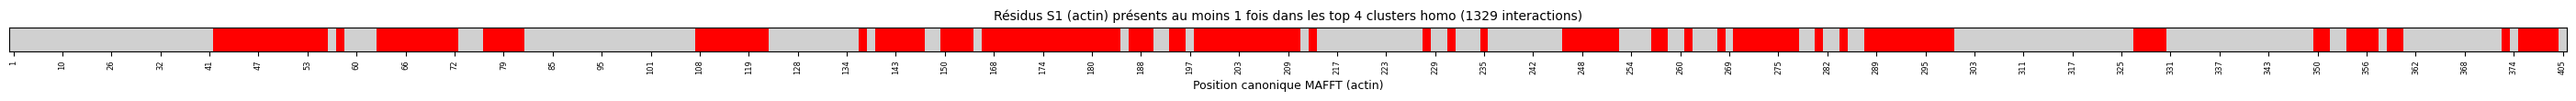

139 positions rouges,174 grises
color white
color red, resi 42+43+44+45+46+47+48+49+50+51+52+53+54+55+57+63+64+65+66+67+68+69+70+71+72+76+77+79+80+81+108+114+115+116+117+118+119+120+121+137+139+140+143+144+146+147+150+151+152+153+167+168+169+170+171+172+173+174+175+176+177+178+179+180+181+182+183+187+188+191+195+196+198+199+200+201+202+203+204+205+206+207+208+209+210+212+228+231+235+246+247+248+249+250+251+252+257+258+261+268+270+271+272+273+274+275+276+277+281+284+288+289+290+291+292+293+294+295+296+297+299+327+328+329+330+350+351+354+355+356+357+359+360+373+376+377+378+379+380


In [9]:
                                                
from matplotlib.colors import ListedColormap
                                                
# Top 4 clusters homo (S1 + S2 confondus) 
iids = {iid for c in sorted(homo_clusters,      
key=lambda c: -c['n'])[:4] for iid in c['iids']}  

canon_used = list(set(df_res[df_res['interaction_id'].isin(iids)]['canon']))                      
used = np.array([1.0 if p in canon_used else 0.0  
for p in all_positions]).reshape(1, -1)         
                                                
fig, ax = plt.subplots(figsize=(max(14,len(all_positions) * 0.09), 1.2))
ax.imshow(used, aspect='auto',cmap=ListedColormap(['#D0D0D0', 'red']), interpolation='none', vmin=0, vmax=1) 
step = max(1, len(all_positions) // 50)           
xticks_idx = list(range(0, len(all_positions),  step))                                            
ax.set_xticks(xticks_idx)
ax.set_xticklabels([all_positions[i] for i in     
xticks_idx], fontsize=6, rotation=90)             
ax.set_xlabel('Position canonique MAFFT (actin)', fontsize=9)                                       
ax.set_yticks([])                               
ax.set_title(f"Résidus S1 (actin) présents au moins 1 fois dans les top 4 clusters homo ({len(iids)} interactions)", fontsize=10)
plt.tight_layout()                                
plt.savefig(VIS_DIR /                           
'actin_s1_top4homo_used_heatmap.png', dpi=150,    
bbox_inches='tight')
plt.show()                                        
                                                
print(f"{len(canon_used)} positions rouges,{len(all_positions) - len(canon_used)} grises")
print(f"color white")                             
print(f"color red, resi {'+'.join(str(r) for r in canon_used)}") 

In [10]:
# ── Heatmaps globaux multi-lignes : homo (haut) + hétéro (bas) ───────────────
# Génère DEUX fichiers :
#   1) actin_s1_all_equitable_heatmap.png  → valeurs RELATIVES (chaque ligne normalisée 0–1)
#   2) actin_s1_heatmap_absolute.png       → valeurs ABSOLUES % ASA buried
# Les deux utilisent la normalisation équitable par sous-cluster C70.

def _draw_global_heatmap(mat_homo, mat_hetero, lbl_homo, lbl_hetero,
                          vmax, cbar_label, title, out_path):
    n_homo   = len(mat_homo)
    n_hetero = len(mat_hetero)
    row_h    = 0.22
    fig_h    = max(10, (n_homo + n_hetero) * row_h + 5)
    fig_w    = max(14, len(all_positions) * 0.09)

    fig = plt.figure(figsize=(fig_w, fig_h))
    gs  = gridspec.GridSpec(
        2, 2,
        height_ratios=[n_homo, n_hetero],
        width_ratios=[1, 0.02],
        hspace=0.04,
        wspace=0.02,
    )
    ax_homo   = fig.add_subplot(gs[0, 0])
    ax_hetero = fig.add_subplot(gs[1, 0])
    ax_cb     = fig.add_subplot(gs[:, 1])

    step       = max(1, len(all_positions) // 50)
    xticks_idx = list(range(0, len(all_positions), step))

    # Section HOMO
    im = None
    if n_homo > 0:
        im = ax_homo.imshow(mat_homo, aspect='auto', cmap='YlOrRd',
                            interpolation='none', vmin=0, vmax=vmax)
        ax_homo.set_xticks(xticks_idx)
        ax_homo.set_xticklabels([])
        ax_homo.set_yticks(range(n_homo))
        ax_homo.set_yticklabels([l.split('  ')[0] for l in lbl_homo], fontsize=5)
        ax_homo.set_title(f'HOMO — actine / actine ({n_homo} clusters)',
                          fontsize=9, loc='left', pad=3)
    else:
        ax_homo.axis('off')

    # Section HÉTÉRO
    if n_hetero > 0:
        im = ax_hetero.imshow(mat_hetero, aspect='auto', cmap='YlOrRd',
                              interpolation='none', vmin=0, vmax=vmax)
        ax_hetero.set_xticks(xticks_idx)
        ax_hetero.set_xticklabels(
            [str(all_positions[i]) for i in xticks_idx], fontsize=5, rotation=90)
        ax_hetero.set_xlabel('Position canonique MAFFT (actine)', fontsize=8)
        ax_hetero.set_yticks(range(n_hetero))
        ax_hetero.set_yticklabels([l.split('  ')[0] for l in lbl_hetero], fontsize=5)
        ax_hetero.set_title(f'HÉTÉRO — actine / ABP ({n_hetero} clusters)',
                            fontsize=9, loc='left', pad=3)
    else:
        ax_hetero.axis('off')

    if im is not None:
        plt.colorbar(im, cax=ax_cb, label=cbar_label)
    fig.suptitle(title, fontsize=10, y=1.001)
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f'Sauvegardé : {out_path}  ({n_homo} homo + {n_hetero} hétéro lignes)')


# ── 1) Version RELATIVE (chaque ligne normalisée par son propre max, 0–1) ────
_draw_global_heatmap(
    mat_homo=mat_homo_eq_raw, mat_hetero=mat_hetero_eq_raw,
    lbl_homo=lbl_homo_eq,     lbl_hetero=lbl_hetero_eq,
    vmax=1.0,
    cbar_label='Score normalisé (0–1, max par cluster)',
    title=('Heatmap globale — tous clusters S1 binding site\n'
           '(valeurs relatives : chaque ligne normalisée par son max, équitable C70)'),
    out_path=VIS_DIR / 'actin_s1_all_equitable_heatmap.png',
)

# ── 2) Version ABSOLUE (% ASA buried, équitable C70, même échelle) ────────────
vmax_abs = max(
    mat_homo_eq_abs.max()   if len(mat_homo_eq_abs)   > 0 else 0,
    mat_hetero_eq_abs.max() if len(mat_hetero_eq_abs) > 0 else 0,
    1.0
)
_draw_global_heatmap(
    mat_homo=mat_homo_eq_abs, mat_hetero=mat_hetero_eq_abs,
    lbl_homo=lbl_homo_eq,     lbl_hetero=lbl_hetero_eq,
    vmax=vmax_abs,
    cbar_label='% ASA buried moyen (équitable C70)',
    title=('Heatmap globale — tous clusters S1 binding site\n'
           '(valeurs absolues % ASA buried, équitable par sous-cluster C70)'),
    out_path=VIS_DIR / 'actin_s1_heatmap_absolute.png',
)

Sauvegardé : ../visualisations/actin_s1_all_equitable_heatmap.png  (26 homo + 150 hétéro lignes)


Sauvegardé : ../visualisations/actin_s1_heatmap_absolute.png  (26 homo + 150 hétéro lignes)


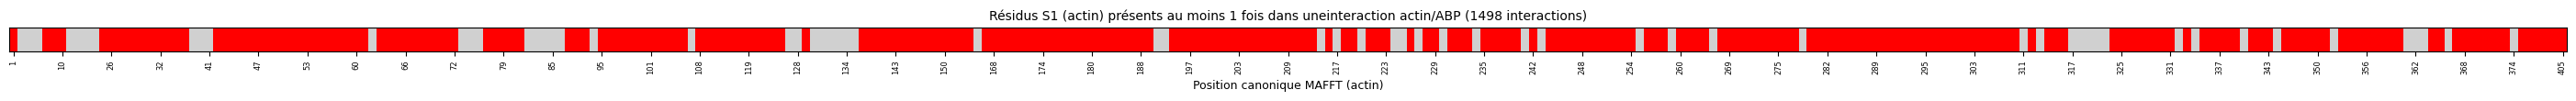

250 positions rouges, 63 positions blanches
[1, 8, 9, 10, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 60, 61, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 76, 77, 79, 80, 81, 88, 91, 92, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 108, 114, 115, 116, 117, 118, 119, 120, 121, 122, 125, 129, 137, 138, 139, 140, 143, 144, 146, 147, 148, 149, 150, 151, 152, 153, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 187, 188, 191, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 215, 218, 219, 221, 222, 223, 226, 228, 229, 231, 232, 233, 235, 236, 238, 239, 240, 242, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253, 254, 256, 257, 258, 260, 261, 263, 264, 268, 269, 270, 271, 272, 273, 274, 275, 276, 277, 280, 281, 282, 283, 284, 285, 287, 288, 289, 290, 291, 292, 293, 294, 295, 296, 297, 299, 300, 301, 303, 304, 307, 308, 309, 310, 312, 314, 315, 

In [11]:

from matplotlib.colors import ListedColormap

actin_chains = set(df_pp[df_pp['is_actin']]['chain'].str.lower())  
homo_iids  = set(df_int[df_int['chain_B_id'].str.lower().isin(actin_chains)]['interaction_id'])                                    
                                                        
canon_used = list(set(df_res[df_res['interaction_id'].isin(homo_iids)]['canon']))
used = np.array([1.0 if p in canon_used else 0.0 for p in all_positions]).reshape(1, -1)                                     

fig, ax = plt.subplots(figsize=(max(14, len(all_positions) * 0.09),
1.2))                                                    
ax.imshow(used, aspect='auto', cmap=ListedColormap(['#D0D0D0','red']),
        interpolation='none', vmin=0, vmax=1)
step = max(1, len(all_positions) // 50)
xticks_idx = list(range(0, len(all_positions), step))
ax.set_xticks(xticks_idx)
ax.set_xticklabels([all_positions[i] for i in xticks_idx],
fontsize=6, rotation=90)
ax.set_xlabel('Position canonique MAFFT (actin)', fontsize=9)
ax.set_yticks([])
ax.set_title(f"Résidus S1 (actin) présents au moins 1 fois dans uneinteraction actin/ABP ({len(homo_iids)} interactions)",
fontsize=10)
plt.tight_layout()
plt.savefig(VIS_DIR / 'actin_s1_homo_used_heatmap.png', dpi=150,
bbox_inches='tight')                                               
plt.show()

print(f"{len(canon_used)} positions rouges, {len(all_positions) - len(canon_used)} positions blanches")                     
print(list(canon_used))

print(f"color white")
print(f"color red, resi {'+'.join(str(r) for r in canon_used)}")

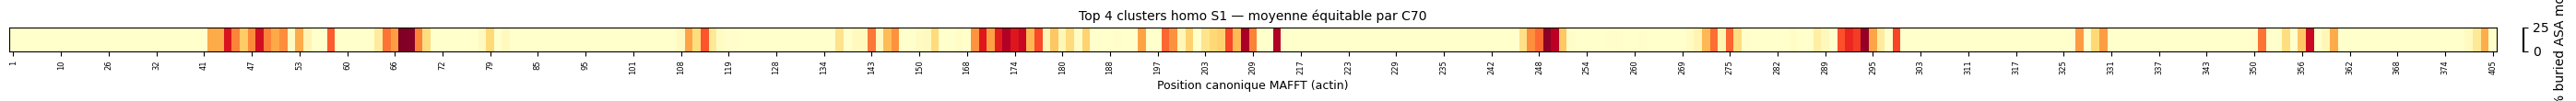

In [12]:
from matplotlib.colors import ListedColormap

rows = []
for c in sorted(homo_clusters, key=lambda c: -c['n'])[:4]:
    c70_groups = {}
    for iid in c['iids']:
        c70 = id_to_c70.get(iid)
        if c70:
            c70_groups.setdefault(c70, set()).add(iid)
    profiles = [
        (
        df_res[(df_res['interaction_id'].isin(iids)) & (df_res['patch'] == c['patch'])]
        .groupby(['interaction_id', 'canon'])['buried_ASA_percent']
        .max()
        .groupby(level='canon').sum()
        / len(iids)
        )
        .reindex(all_positions, fill_value=0).fillna(0).values.astype(float)
        for iids in c70_groups.values()
        if not df_res[(df_res['interaction_id'].isin(iids)) & (df_res['patch'] == c['patch'])].empty
    ]
    vals = np.mean(profiles, axis=0) if profiles else np.zeros(len(all_positions))
    rows.append(vals)

mean_mat = np.array(rows).mean(axis=0).reshape(1, -1)

fig, ax = plt.subplots(figsize=(max(14, len(all_positions) * 0.09), 1.2))
im = ax.imshow(mean_mat, aspect='auto', cmap='YlOrRd',
               interpolation='none', vmin=0, vmax=mean_mat.max())
step = max(1, len(all_positions) // 50)
xticks_idx = list(range(0, len(all_positions), step))
ax.set_xticks(xticks_idx)
ax.set_xticklabels([all_positions[i] for i in xticks_idx], fontsize=6, rotation=90)
ax.set_xlabel('Position canonique MAFFT (actin)', fontsize=9)
ax.set_yticks([])
ax.set_title("Top 4 clusters homo S1 — moyenne équitable par C70", fontsize=10)
plt.colorbar(im, ax=ax, fraction=0.015, pad=0.01, label='% buried ASA moyen')
plt.tight_layout()
plt.savefig(VIS_DIR / 'actin_s1_homo_top4_mean_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

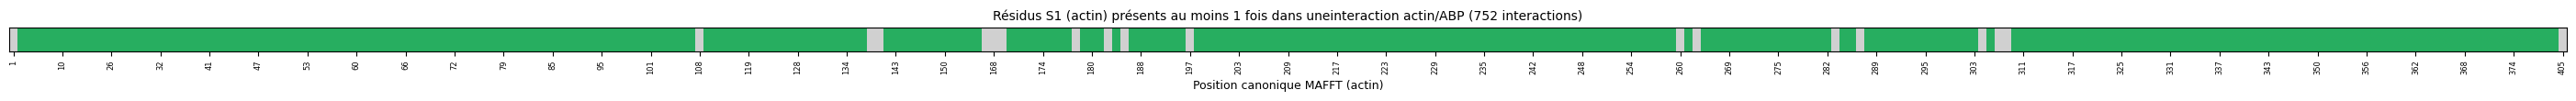

294 positions vertes, 19 positions blanches
[5, 6, 7, 8, 9, 10, 11, 12, 20, 22, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 39, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 79, 80, 81, 82, 83, 84, 85, 87, 88, 91, 92, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 114, 115, 116, 117, 118, 119, 120, 121, 122, 125, 126, 128, 129, 130, 131, 132, 133, 134, 135, 137, 140, 143, 144, 146, 147, 148, 149, 150, 151, 152, 153, 162, 170, 171, 172, 173, 174, 175, 176, 177, 179, 180, 181, 183, 187, 188, 191, 192, 194, 195, 196, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 214, 215, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 238, 239, 240, 241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253, 254, 255, 256, 257, 258, 259, 261, 264, 267, 268, 269, 270, 271, 272, 273, 274, 275, 276, 277, 278, 2

In [13]:

from matplotlib.colors import ListedColormap

actin_chains = set(df_pp[df_pp['is_actin']]['chain'].str.lower())  
hetero_iids  = set(df_int[~df_int['chain_B_id'].str.lower().isin(actin_chains)]['interaction_id'])                                    
                                                        
canon_used = list(set(df_res[df_res['interaction_id'].isin(hetero_iids)]['canon']))
used = np.array([1.0 if p in canon_used else 0.0 for p in all_positions]).reshape(1, -1)                                     

fig, ax = plt.subplots(figsize=(max(14, len(all_positions) * 0.09),
1.2))                                                    
ax.imshow(used, aspect='auto', cmap=ListedColormap(['#D0D0D0','#27AE60']),
        interpolation='none', vmin=0, vmax=1)
step = max(1, len(all_positions) // 50)
xticks_idx = list(range(0, len(all_positions), step))
ax.set_xticks(xticks_idx)
ax.set_xticklabels([all_positions[i] for i in xticks_idx],
fontsize=6, rotation=90)
ax.set_xlabel('Position canonique MAFFT (actin)', fontsize=9)
ax.set_yticks([])
ax.set_title(f"Résidus S1 (actin) présents au moins 1 fois dans uneinteraction actin/ABP ({len(hetero_iids)} interactions)",
fontsize=10)
plt.tight_layout()
plt.savefig(VIS_DIR / 'actin_s1_hetero_used_heatmap.png', dpi=150,
bbox_inches='tight')                                               
plt.show()

print(f"{len(canon_used)} positions vertes, {len(all_positions) - len(canon_used)} positions blanches")                     
print(list(canon_used))

print(f"color gray70")
print(f"color 0x27AE60, resi {'+'.join(str(r) for r in canon_used)}")



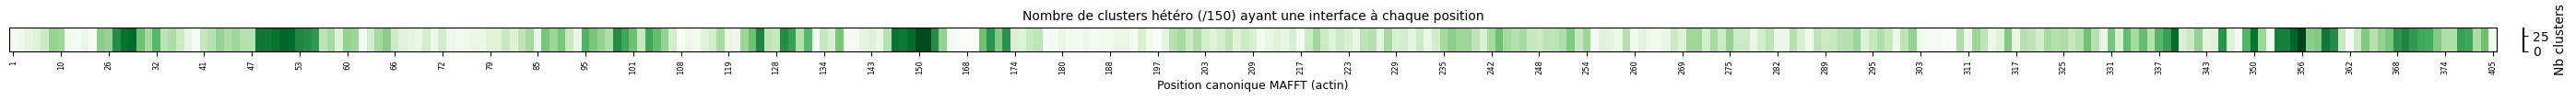

In [14]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt

rows = []
for c in hetero_clusters:
    c70_groups = {}
    for iid in c['iids']:
        c70 = id_to_c70.get(iid)
        if c70:
            c70_groups.setdefault(c70, set()).add(iid)
    profiles = [
        (
        df_res[(df_res['interaction_id'].isin(iids)) & (df_res['patch'] == c['patch'])]
        .groupby(['interaction_id', 'canon'])['buried_ASA_percent']
        .max()
        .groupby(level='canon').sum()
        / len(iids)
        )
        .reindex(all_positions, fill_value=0).fillna(0).values.astype(float)
        for iids in c70_groups.values()
        if not df_res[(df_res['interaction_id'].isin(iids)) & (df_res['patch'] == c['patch'])].empty
    ]
    vals = np.mean(profiles, axis=0) if profiles else np.zeros(len(all_positions))
    rows.append(vals >= 0.01)

count_mat = np.sum(np.array(rows), axis=0).reshape(1, -1)

fig, ax = plt.subplots(figsize=(max(14, len(all_positions) * 0.09), 1.2))
im = ax.imshow(count_mat, aspect='auto', cmap='Greens',
               interpolation='none', vmin=0, vmax=count_mat.max())
step = max(1, len(all_positions) // 50)
xticks_idx = list(range(0, len(all_positions), step))
ax.set_xticks(xticks_idx)
ax.set_xticklabels([all_positions[i] for i in xticks_idx], fontsize=6, rotation=90)
ax.set_xlabel('Position canonique MAFFT (actin)', fontsize=9)
ax.set_yticks([])
ax.set_title(f"Nombre de clusters hétéro (/{len(hetero_clusters)}) ayant une interface à chaque position", fontsize=10)
plt.colorbar(im, ax=ax, fraction=0.015, pad=0.01, label='Nb clusters')
plt.tight_layout()
plt.savefig(VIS_DIR / 'actin_s1_hetero_count_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Heatmaps par cluster S1 — un PNG par patch

In [15]:
# ── Heatmaps par cluster S1 (un PNG par patch) ────────────────────────────
# Charge actin_s1_canon_area_by_cluster.csv (valeurs absolues % ASA buried, équitable C70)
# et génère un heatmap mono-ligne par patch.

OUT_CLUSTER = VIS_DIR / 'actin_s1_clusters'
OUT_CLUSTER.mkdir(parents=True, exist_ok=True)

df_area = pd.read_csv(FILTERED / 'actin_s1_canon_area_by_cluster.csv', index_col='patch')
positions = [str(p) for p in df_area.columns.tolist()]
vmax_global = max(float(df_area.values.max()), 1.0)

for patch, row in df_area.iterrows():
    vals = row.values.astype(float).reshape(1, -1)

    fig, ax = plt.subplots(figsize=(max(14, len(positions) * 0.09), 1.5))
    im = ax.imshow(vals, aspect='auto', cmap='YlOrRd', interpolation='none',
                   vmin=0, vmax=vmax_global)

    step = max(1, len(positions) // 50)
    xticks_idx = list(range(0, len(positions), step))
    ax.set_xticks(xticks_idx)
    ax.set_xticklabels([positions[i] for i in xticks_idx], fontsize=6, rotation=90)
    ax.set_yticks([])
    ax.set_title(f'Patch {patch} — profil interface S1 (% ASA buried absolu, équitable C70)',
                 fontsize=9)
    ax.set_xlabel('Position canonique MAFFT (actine)', fontsize=8)
    plt.colorbar(im, ax=ax, shrink=0.8, label='% ASA buried moyen')
    plt.tight_layout()
    plt.savefig(OUT_CLUSTER / f'{patch}.png', dpi=150, bbox_inches='tight')
    plt.close()

print(f"Sauvegardé : {len(df_area)} heatmaps → {OUT_CLUSTER}/")

Sauvegardé : 176 heatmaps → ../visualisations/actin_s1_clusters/


## Heatmaps par cluster S1 — décomposition par sous-cluster C70

In [16]:
# ── Heatmaps par cluster S1, décomposé par sous-cluster C70 ─────────────
# Un PNG par patch : une ligne par sous-cluster C70.
# Montre comment le même patch S1 se manifeste différemment selon le C70.

OUT_BY_C70 = VIS_DIR / 'actin_s1_clusters_by_c70'
OUT_BY_C70.mkdir(parents=True, exist_ok=True)

MIN_IIDS = 2  # seuil minimum d'interactions pour afficher un sous-cluster

all_s1_clusters = homo_clusters + hetero_clusters
saved = 0

for c in all_s1_clusters:
    patch = c['patch']

    # Grouper les interaction_ids de ce patch par sous-cluster C70
    c70_groups = {}
    for iid in c['iids']:
        c70 = id_to_c70.get(iid)
        if c70 is not None:
            c70_groups.setdefault(str(c70), set()).add(iid)

    # Filtrer les C70 avec assez d'interactions
    c70_groups = {c70: iids for c70, iids in c70_groups.items()
                  if len(iids) >= MIN_IIDS}
    if not c70_groups:
        continue

    rows, labels = [], []
    for c70, iids in sorted(c70_groups.items(), key=lambda x: -len(x[1])):
        sub = df_res[
            df_res['interaction_id'].isin(iids) &
            (df_res['patch'] == patch)
        ]
        if sub.empty:
            continue
        profile = (
            sub.groupby(['interaction_id', 'canon'])['buried_ASA_percent']
            .max()
            .groupby(level='canon').sum()
            / len(iids)
        ).reindex(all_positions, fill_value=0).fillna(0).values.astype(float)
        rows.append(profile)
        labels.append(f'C70={c70}  (n={len(iids)})')

    if not rows:
        continue

    mat = np.array(rows)
    n_rows = len(rows)
    vmax = mat.max() if mat.max() > 0 else 1.0

    fig, ax = plt.subplots(
        figsize=(max(14, len(all_positions) * 0.09), max(2, n_rows * 0.45 + 1.2))
    )
    im = ax.imshow(mat, aspect='auto', cmap='YlOrRd', interpolation='none',
                   vmin=0, vmax=vmax)
    step = max(1, len(all_positions) // 50)
    xticks_idx = list(range(0, len(all_positions), step))
    ax.set_xticks(xticks_idx)
    ax.set_xticklabels([str(all_positions[i]) for i in xticks_idx],
                       fontsize=6, rotation=90)
    ax.set_yticks(range(n_rows))
    ax.set_yticklabels(labels, fontsize=7)
    ax.set_title(f'Patch {patch} — décomposition par sous-cluster C70', fontsize=9)
    ax.set_xlabel('Position canonique MAFFT (actine)', fontsize=8)
    plt.colorbar(im, ax=ax, shrink=0.8, label='% ASA buried moyen / interaction')
    plt.tight_layout()
    plt.savefig(OUT_BY_C70 / f'{patch}.png', dpi=150, bbox_inches='tight')
    plt.close()
    saved += 1

print(f"Sauvegardé : {saved} heatmaps → {OUT_BY_C70}/")

Sauvegardé : 104 heatmaps → ../visualisations/actin_s1_clusters_by_c70/
